# 局部加权线性回归

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def load_dataset(csv_path,label_col='y',add_bias=False): # 省略列名？添加截距？ 
    with open(csv_path,'r') as csv_fh:
        headers=csv_fh.readline().strip().split(',')
    x_cols=[i for i in range(len(headers)) if headers[i].startswith('x')]
    l_cols=[i for i in range(len(headers)) if headers[i] == label_col]
    inputs=np.loadtxt(csv_path,delimiter=',',skiprows=1,usecols=x_cols)
    labels=np.loadtxt(csv_path,delimiter=',',skiprows=1,usecols=l_cols)

    if inputs.ndim==1:
        inputs=inputs.reshape(-1,1)

    return inputs,labels


Mean Square Error: 0.3365507639747307


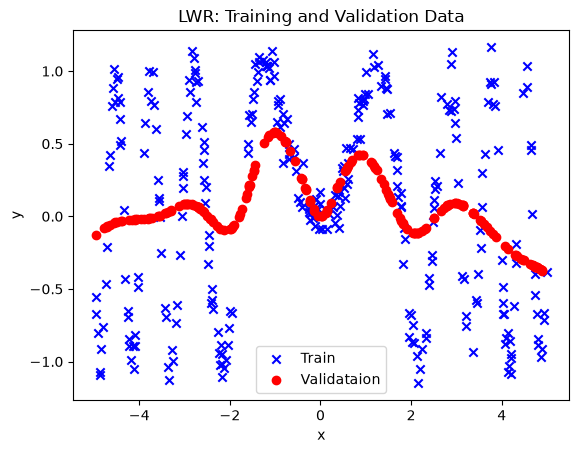

In [25]:
class LocallyWeightedLinearRegression:
    def __init__(self,tau):
        self.tau=tau
        self.x=None
        self.y=None
        self.last_theta=None

    def fit(self,x,y):
        self.x=x
        self.y=y

    def predict(self,x):
        predictions=[]

        for input_x in x:
            distances=np.linalg.norm(self.x-input_x,axis=1)
            weights=np.diag(np.exp(-1*distances**2/(2*self.tau**2)))
            self.last_theta=np.linalg.inv(self.x.T @ weights @ self.x) @ self.x.T @ weights @ self.y
            predictions.append(self.last_theta.T @ input_x)

        return np.array(predictions)
    
def main(tau,train_path,val_path):
    x_train,y_train=load_dataset(train_path,'y',True)

    lwr=LocallyWeightedLinearRegression(tau)
    lwr.fit(x_train,y_train)

    x_val,y_val=load_dataset(val_path,'y',True)
    predictions=lwr.predict(x_val)

    mse_val=np.mean((predictions-y_val)**2)
    print(f"Mean Square Error: {mse_val}")

    plt.figure()
    plt.scatter(x_train[:,0],y_train,c='b',marker='x',label='Train')
    plt.scatter(x_val[:,0],predictions,c='r',marker='o',label='Validataion')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.title("LWR: Training and Validation Data")
    plt.show()

if __name__=='__main__':
    main(0.5,'./train.csv','./valid.csv')
        